In [ ]:
#Άσκηση 4 συνέχεια

In [ ]:
#Ο παρακάτω κώδικας υπολογίζει τα διαστήματα εμπιστοσύνης για τις παραμέτρους µ 
#και σ^2 για όλες τις τιμές του k. Ένα παράδειγμα εξόδου φαίνεται παρακάτω.

In [58]:
import numpy as np
import scipy.stats as stats
mu = 20
sigma = 2
CL = 0.90
alpha = 1 - CL
k_values = [5, 20, 50]
for k in k_values:
    sample = np.random.normal(mu, sigma, k)
    x_bar = np.mean(sample)
    s2 = np.var(sample, ddof=1)
    s = np.sqrt(s2)

    # Διάστημα εμπιστοσύνης για τον μέσο
    t_crit = stats.t.ppf(1 - alpha / 2, df=k - 1)
    margin_mean = t_crit * s / np.sqrt(k)
    ci_mean = (x_bar - margin_mean, x_bar + margin_mean)

    # Διάστημα εμπιστοσύνης για διασπορά
    chi2_lower = stats.chi2.ppf(1 - alpha / 2, df=k - 1)
    chi2_upper = stats.chi2.ppf(alpha / 2, df=k - 1)
    ci_var = ((k - 1) * s2 / chi2_lower, (k - 1) * s2 / chi2_upper)

    print(f"For N = {k}")
    print(f"Ο μέσος όρος της κατανομής είναι μεταξύ:{ci_mean[0]:.2f} και {ci_mean[1]:.2f}")
    print(f"Η   διασπορά της κατανομής είναι μεταξύ: {ci_var[0]:.2f} και {ci_var[1]:.2f}\n")

For N = 5
Ο μέσος όρος της κατανομής είναι μεταξύ:18.33 και 20.49
Η   διασπορά της κατανομής είναι μεταξύ: 0.54 και 7.25

For N = 20
Ο μέσος όρος της κατανομής είναι μεταξύ:19.73 και 21.10
Η   διασπορά της κατανομής είναι μεταξύ: 1.99 και 5.92

For N = 50
Ο μέσος όρος της κατανομής είναι μεταξύ:19.40 και 20.28
Η   διασπορά της κατανομής είναι μεταξύ: 2.54 και 4.97



In [ ]:
#Σε όλες τις περιπτώσεις περιλαμβάνονται οι πραγματικές τιμές µ και σ^2.
#Είναι εμφανές ωστόσο ότι αυξανόμενης τις τιμής του N τα αντίστοιχα διαστήματα όλο και
# μικραίνουν, το οποίο είναι αναμενόμενο. Όσο μεγαλώνει το πλήθος του δείγματος,
#τόσο ακριβέστερη θα περιμέναμε να είναι η εκτίμηση.Παρακάτω παρουσιάζεται η συνέχεια 
# του κώδικα, όπου γίνονται οι ζητούμενες 1000 επαναλήψεις.

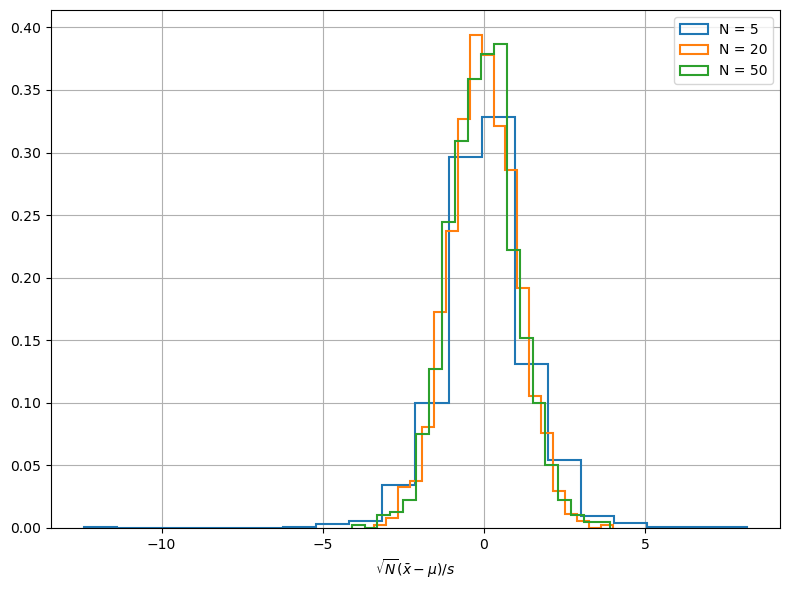

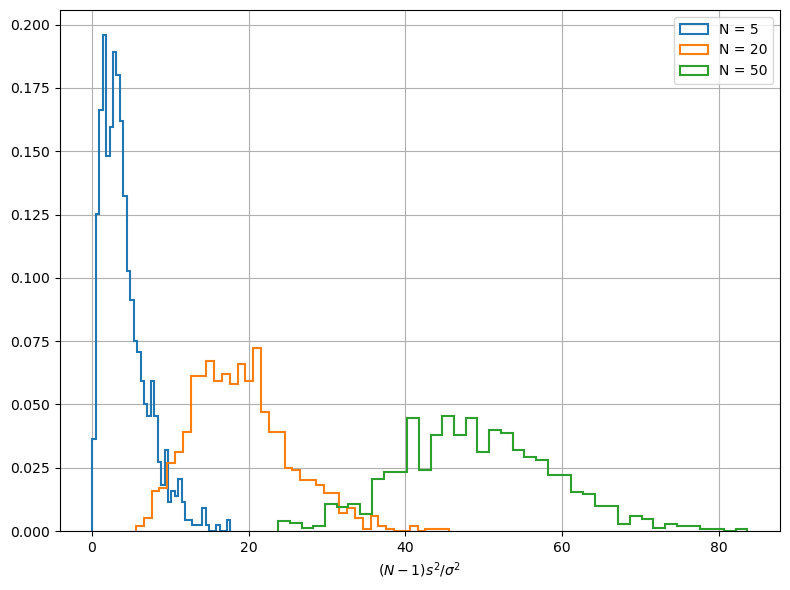

For N = 5:
Percentage of mean confidence intervals containing true mu: 89.2%
Percentage of variance confidence intervals containing true sigma^2: 90.4%

For N = 20:
Percentage of mean confidence intervals containing true mu: 90.9%
Percentage of variance confidence intervals containing true sigma^2: 89.5%

For N = 50:
Percentage of mean confidence intervals containing true mu: 89.4%
Percentage of variance confidence intervals containing true sigma^2: 89.3%



In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, chi2
# Ορισμός πραγματικών παραμέτρων
mu = 20
sigma = 2
sigma2 = sigma ** 2
CL = 0.90
z = (1 + CL) / 2
# Τιμές Ν
sample_sizes = [5, 20, 50]
num_samples = 1000
# Για αποθήκευση αποτελεσμάτων
all_a_stats = {}
all_b_stats = {}
summary = []

for n in sample_sizes:
    a_stats = []
    b_stats = []
    count_mean_CI = 0
    count_var_CI = 0
    alpha = 1 - CL

    for _ in range(num_samples):
        sample = np.random.normal(mu, sigma, n)
        xbar = np.mean(sample)
        s = np.std(sample, ddof=1)
        s2 = s ** 2

        # (α) στατιστική ποσότητα
        t_stat = np.sqrt(n) * (xbar - mu) / s
        a_stats.append(t_stat)

        # (β) στατιστική ποσότητα
        chi_stat = (n - 1) * s2 / sigma2
        b_stats.append(chi_stat)

        # Διάστημα εμπιστοσύνης για τη μέση τιμή (t-student)
        t_crit = t.ppf(1 - alpha / 2, df=n - 1)
        CI_mean = (xbar - t_crit * s / np.sqrt(n), xbar + t_crit * s / np.sqrt(n))
        if CI_mean[0] <= mu <= CI_mean[1]:
            count_mean_CI += 1

        # Διάστημα εμπιστοσύνης για τη διασπορά (chi-squared)
        chi2_lower = chi2.ppf(alpha / 2, df=n - 1)
        chi2_upper = chi2.ppf(1 - alpha / 2, df=n - 1)
        CI_var = ((n - 1) * s2 / chi2_upper, (n - 1) * s2 / chi2_lower)
        if CI_var[0] <= sigma2 <= CI_var[1]:
            count_var_CI += 1

    # Αποθήκευση
    all_a_stats[n] = a_stats
    all_b_stats[n] = b_stats

    # Υπολογισμός ποσοστών
    mean_CI_percent = count_mean_CI / num_samples * 100
    var_CI_percent = count_var_CI / num_samples * 100
    summary.append(f"For N = {n}:\n"
    f"Percentage of mean confidence intervals containing true mu: {mean_CI_percent:.1f}%\n"
    f"Percentage of variance confidence intervals containing true sigma^2: {var_CI_percent:.1f}%\n")

# A ζητούμενο 
plt.figure(figsize=(8,6))
for n, data in all_a_stats.items():
    plt.hist(data, bins=20, density=True, histtype='step', label=f'N = {n}', linewidth=1.5)
plt.xlabel(r'$\sqrt{N} (\bar{x} - \mu)/s$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("a_question_hist.png")
plt.show()
#Β ζητούμενο
plt.figure(figsize=(8, 6))
for n, data in all_b_stats.items():
    plt.hist(data, bins=40, density=True, histtype='step', label=f'N = {n}', linewidth=1.5)
plt.xlabel(r'$(N-1) s^2 / \sigma^2$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("b_question_hist.png")
plt.show()

# -------- Εκτύπωση αποτελεσμάτων --------
for line in summary:
    print(line)

In [ ]:
#Όσον αφορά τα ιστογράμματα, ο παραπάνω κώδικας δίνει τα παραπάνω.
#Εικόνα 1:Ιστογράμματα της ποσόστητας √N*(x^~ -μ)/s για κάθε τιμή του N
#Εικόνα 2:Ιστογράμματα της ποσότητας (N−1)s^2/σ^2 για κάθε τιμή του N
#Για το πρώτο γράφημα και τα τρία ιστογράμματα φαίνονται να μοιάζουν με κανονική κατανομή 
#με κέντρο το 0, της οποίας το ύψος μεγαλώνει με την ανάλογη μείωση του 
#πλάτους καθώς αυξάνεται το N. Στο δεύτερο γράφημα, και οι τρεις κατανομές 
# παρουσιάζουν μέγιστα στην τιμή που αντιστοιχεί περίπου στο N, όπως ήταν αναμενόμενο αφού 
#ιδανικά s^2/σ^2 =1.Καθώς, αυξάνεται η τιμή του N, η κατανομή γίνεται πιο συμμετρική 
# γύρω από τη μέγιστη τιμή της δηλαδή,τείνει στην κανονική κατανομή.Όπως φαίνεται για την καμπύλη N = 50, 
#ειδικά συγκρίνοντάς την με την καμπύλη N = 5.Για τα ποσοστά επιτυχίας,
# ο παραπάνω κώδικας έδωσε αυτά που βλέπουμε στο τέλος των γραφημάτων.